In [4]:
# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

관찰 결과: 200번 시도 중 12번 성공 (관찰 성공률 6.0%)

[이항검정 결과]
p-값: 0.0320
p-값(0.0320) < 유의수준(0.05)
→ 귀무가설 기각: 실제 확률이 10%보다 낮다는 증거가 충분합니다.


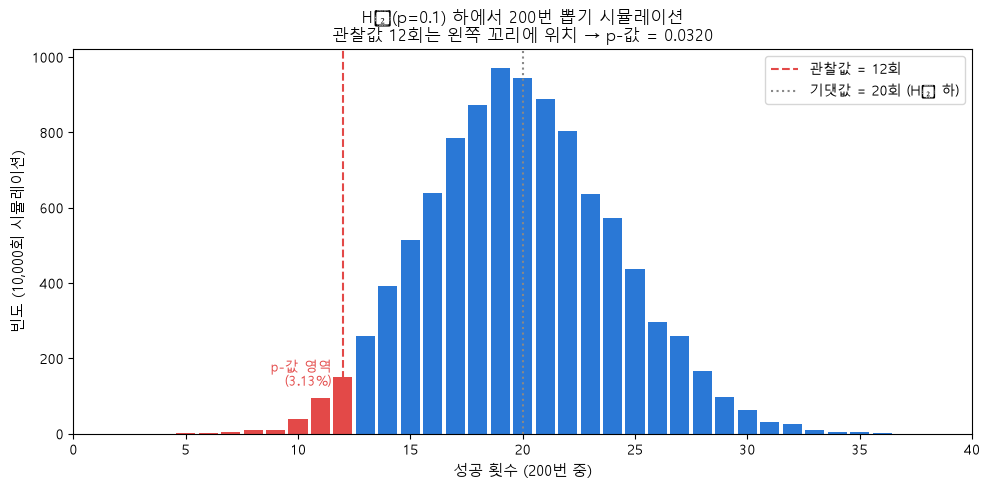

In [5]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── 기본 설정 ──────────────────────────────────────
n = 200   # 총 시행 횟수
x = 12    # 관찰된 성공 횟수
p = 0.1   # 귀무가설에서의 성공 확률

print(f"관찰 결과: {n}번 시도 중 {x}번 성공 (관찰 성공률 {x/n:.1%})")

# ── 1. 가설 설정 ───────────────────────────────────
# H₀: p = 0.10  →  개발사 주장이 맞다 (귀무가설, 현상 유지)
# H₁: p < 0.10  →  실제 확률이 더 낮다 (대립가설, 단측검정)

# ── 2. 이항검정 수행 ────────────────────────────────
result = stats.binomtest(x, n, p, alternative='less')
p_value = result.pvalue

print(f"\n[이항검정 결과]")
print(f"p-값: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"p-값({p_value:.4f}) < 유의수준({alpha})")
    print("→ 귀무가설 기각: 실제 확률이 10%보다 낮다는 증거가 충분합니다.")
else:
    print(f"p-값({p_value:.4f}) >= 유의수준({alpha})")
    print("→ 귀무가설 채택: 10% 주장을 기각할 증거가 불충분합니다.")

# ── 3. 시뮬레이션 ───────────────────────────────────
np.random.seed(42)
simulations = np.random.binomial(n=n, p=p, size=10_000)

# ── 4. 히스토그램 시각화 ────────────────────────────
plt.rcParams["font.family"] = "Malgun Gothic"  # Windows 한글 폰트
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(10, 5))

# 관찰값 이하 (p-값 영역) 강조
bins = np.arange(0, 41) - 0.5
counts, edges = np.histogram(simulations, bins=bins)

for i, count in enumerate(counts):
    k = i  # 성공 횟수
    color = "#e34948" if k <= x else "#2a78d6"
    ax.bar(k, count, color=color, width=0.85, linewidth=0)

ax.axvline(x=x, color="#e34948", linestyle="--", linewidth=1.5,
           label=f"관찰값 = {x}회")
ax.axvline(x=n * p, color="#888", linestyle=":", linewidth=1.5,
           label=f"기댓값 = {n*p:.0f}회 (H₀ 하)")

# p-값 영역 레이블
p_region_count = (simulations <= x).sum()
ax.text(x - 0.5, counts[:x+1].max() * 0.85,
        f"p-값 영역\n({p_region_count/100:.2f}%)",
        ha="right", color="#e34948", fontsize=10)

ax.set_xlabel("성공 횟수 (200번 중)", fontsize=11)
ax.set_ylabel("빈도 (10,000회 시뮬레이션)", fontsize=11)
ax.set_title(f"H₀(p=0.1) 하에서 200번 뽑기 시뮬레이션\n"
             f"관찰값 {x}회는 왼쪽 꼬리에 위치 → p-값 = {p_value:.4f}", fontsize=12)
ax.set_xlim(0, 40)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [6]:
from scipy import stats

# 원래: n=200, x=12 (성공률 6%)
result_200 = stats.binomtest(12, 200, 0.1, alternative='less')

# 새로운: n=1000, x=60 (성공률 동일하게 6%)
result_1000 = stats.binomtest(60, 1000, 0.1, alternative='less')

print(f"n=200,  x=12  → p-값: {result_200.pvalue:.6f}")
print(f"n=1000, x=60  → p-값: {result_1000.pvalue:.6f}")

n=200,  x=12  → p-값: 0.032047
n=1000, x=60  → p-값: 0.000004


### 1. 귀무가설
  - 게임사의 주장이 맞다(확률이 10%이다)
### 2. 대립가설
  - 게임사의 주장은 틀리다(확률이 10%보다 더 낮다)

▸
Q2에서 구한 p-값은 시뮬레이션 그래프의 어느 부분에 해당하며, 무엇을 의미하나요?
  - 귀무가설(p=0.10)이 참이라면 200번 중 12번 이하가 나올 확률 - p값의 정의
  위 그래프에서 빨간색 부분이 p값이며 면적이 약 0.320이 나온다.

▸
시뮬레이션 그래프를 볼 때, 우리가 관찰한 '12회 성공'은 개발사의 주장이 맞다는 가정 하에 흔한 일인가요, 드문 일인가요?
  - 드문일이다. 200번 뽑아서 12번이 나올 확률은 10,000번 시뮬레이션 중 335번에 불과하다

▸
이 시뮬레이션 경험을 통해 "p-값이 작으면 귀무가설을 기각한다"는 규칙을 친구에게 어떻게 더 쉽게 설명할 수 있을까요?
  - 예를 들어 정상적인 동전을 던졌을때 앞뒤가 나올 확률은 0.5이다. 그럼 동전이 정상이다라는 것이 귀무가설이 된다.
  하지만 실제 동전을 10번 던져 보았을때 앞면이 한번 이하로 나올 확률은 약1%에 불과하다. 이는 100번중 1번에 불과한 아주 낮은 확률이므로
  이 일이 실제로 일어났다면 이 동전은 정상이 아니다 라고 생각할 수 있고 이 과정이 p값이 작으면 귀무가설을 기각하고 
  대립가설을 선택하는 과정이 된다.
  
▸
만약 200번이 아니라 1,000번을 뽑아 같은 성공률(6%)이 나왔다면, p-값은 어떻게 달라질까요?
  - p값이 0.000004로 낮아진다. 이유는 표본이 클수록 분포가 좁기 때문이다. 1000번을 수행한 경우 
  꼬리 근처에서도 거의 맨 끝에 위치하게 된다.

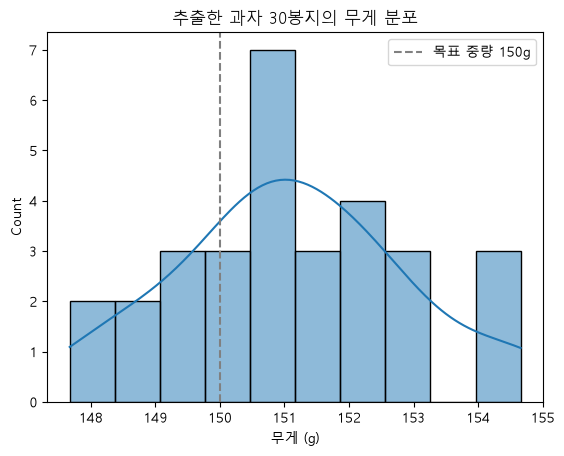

In [7]:
# 데이터 생성 (과자 30봉지의 무게 측정값)
np.random.seed(42)
sample_weights = np.random.normal(loc=151.5, scale=2, size=30)
pop_mean = 150  # 목표 중량 (모평균)

# 표본 분포 시각화
sns.histplot(sample_weights, bins=10, kde=True)
plt.axvline(x=pop_mean, color='gray', linestyle='--', label='목표 중량 150g')
plt.title("추출한 과자 30봉지의 무게 분포")
plt.xlabel("무게 (g)")
plt.legend()
plt.show()

### 귀무가설
  - 목표 중량을 맞추고 있다
### 대립가설
  - 목표 중량을 맞추고 있지 않다.

표본 평균: 151.124g
표본 표준편차: 1.800g
t-통계량: 3.4193
p-값: 0.001883

[결론]
p-값(0.0019) < 유의수준(0.05)
→ 귀무가설 기각: 평균 중량이 150g과 유의미하게 다릅니다.


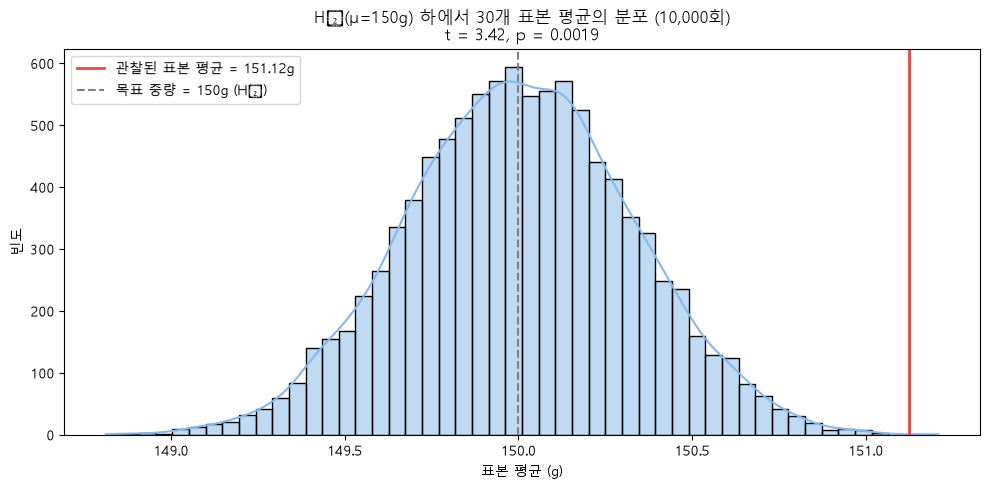

In [8]:
from scipy import stats

# ── 데이터 설정 ────────────────────────────────────
np.random.seed(42)
sample_weights = np.random.normal(loc=151.5, scale=2, size=30)
pop_mean = 150  # 목표 중량 (모평균)

# ── 1. 가설 설정 ───────────────────────────────────
# H₀: μ = 150  →  목표 중량을 맞추고 있다 (귀무가설)
# H₁: μ ≠ 150  →  목표 중량과 맞지 않다 (대립가설, 양측검정)

# ── 2. 일표본 t-검정 수행 ──────────────────────────
t_stat, p_value = stats.ttest_1samp(sample_weights, pop_mean)

sample_mean = sample_weights.mean()
sample_std = sample_weights.std(ddof=1)  # 표본표준편차 (n-1)

print(f"표본 평균: {sample_mean:.3f}g")
print(f"표본 표준편차: {sample_std:.3f}g")
print(f"t-통계량: {t_stat:.4f}")
print(f"p-값: {p_value:.6f}")

alpha = 0.05
print(f"\n[결론]")
if p_value < alpha:
    print(f"p-값({p_value:.4f}) < 유의수준({alpha})")
    print("→ 귀무가설 기각: 평균 중량이 150g과 유의미하게 다릅니다.")
else:
    print(f"p-값({p_value:.4f}) >= 유의수준({alpha})")
    print("→ 귀무가설 채택: 150g과 다르다는 증거가 불충분합니다.")

# ── 3. 시뮬레이션: "평균이 정확히 150g이라면" ──────
# 귀무가설이 참(μ=150)이라는 가정 하에, 30개짜리 표본을 10,000번 뽑아
# 각 표본의 평균이 어떻게 분포하는지 확인
np.random.seed(0)
n = 30
sim_means = np.array([
    np.random.normal(loc=pop_mean, scale=sample_std, size=n).mean()
    for _ in range(10_000)
])

# ── 4. 히스토그램 시각화 ───────────────────────────
plt.rcParams["font.family"] = "Malgun Gothic"  # Windows 한글 폰트
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(sim_means, bins=50, kde=True, color="#85B7EB", ax=ax)

# 관찰된 표본 평균 표시
ax.axvline(x=sample_mean, color="#e34948", linestyle="-", linewidth=2,
           label=f"관찰된 표본 평균 = {sample_mean:.2f}g")
ax.axvline(x=pop_mean, color="gray", linestyle="--", linewidth=1.5,
           label=f"목표 중량 = {pop_mean}g (H₀)")

ax.set_title(f"H₀(μ=150g) 하에서 30개 표본 평균의 분포 (10,000회)\n"
             f"t = {t_stat:.2f}, p = {p_value:.4f}")
ax.set_xlabel("표본 평균 (g)")
ax.set_ylabel("빈도")
ax.legend()
plt.tight_layout()
plt.show()

▸
Q5의 히스토그램은 무엇을 나타내나요? 이 분포의 모양이 정규분포와 비슷한 이유는 무엇일까요? (힌트: 4장에서 배운 중심극한정리)
  - 중심극한정리의 핵심은 모집단의 분포에 상관없이 표본평균을 여러번 모아서 모으면 그 평균들의 분포는 항상 정규분포에 가까워진다는 것이다.
  우리는 표본들을 뽑아서 평균을 내는것을 10,000번 반복했기 때문에 이러한 분포가 나온다.

▸
우리가 실제로 관찰한 표본 평균(세로선)은 이 분포에서 흔하게 나타나는 값인가요? Q2의 p-값과 이 시각적 위치는 어떻게 관련되나요?
  - 흔하게 나타나는 값이 아님. p값과 시각적 위치는 반비례 한다. p값이 중심분포에서 멀어질수록 바깥 꼬리 면적은 줄어든다.

▸
만약 p-값이 0.001이었다면, 세로선은 그래프의 어디쯤에 위치할 것으로 예상되나요?
  - 현재 p값이 0.0019이기 때문에 큰 차이는 없을거라고 생각된다.
  하지만 이 역시 유의수준보다 작기 때문에 귀무가설을 기가해야한다.

▸
이 결과는 공장 입장에서 어떤 조치를 취해야 함을 시사할까요? (목표보다 무겁게 나오는 것은 어떤 손실일까요?)
  - 검정 결과는 귀무가설(평균 중량을 맞추고 있다)을 기각하고 대립가설(평균 중량을 맞추지 못하고 있다)을 선택해야 함을 보여준다.
  목표보다 무겁게 나오고 있는 것은 공장입장에서 손실을 보고 있기 때문에 설비를 목표 중량과 맞게 다시 설정해야 한다.
  또한 정기적으로 검정을 통해 이를 맞춰줘야 한다.

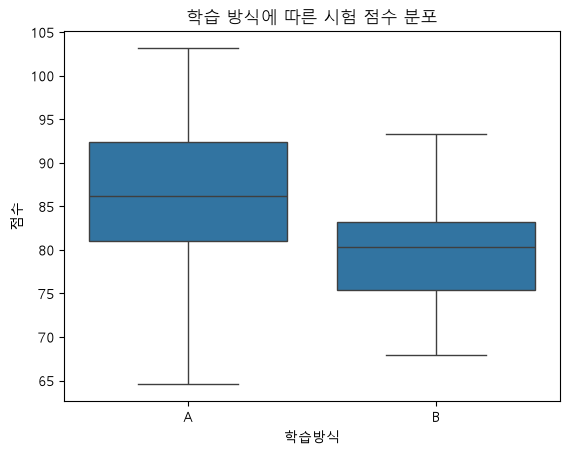

[Q1] 정규성 검정 (Shapiro-Wilk)
A그룹 - 통계량: 0.9876, p-값: 0.8766
B그룹 - 통계량: 0.9866, p-값: 0.8366
→ A그룹: p=0.8766 > 0.05, 정규성 가정 만족 ✓
→ B그룹: p=0.8366 > 0.05, 정규성 가정 만족 ✓

[Q2] 등분산성 검정 (Levene's test)
통계량: 6.1330, p-값: 0.0150
→ p=0.0150 ≤ 0.05, 등분산성 가정 위반 → Welch's t-검정 사용 ✗

[Q3] 이표본 t-검정 (equal_var=False)
A그룹 평균: 86.124점
B그룹 평균: 79.853점
관찰된 평균 차이 (A-B): 6.271점
t-통계량: 4.0426
p-값: 0.000115
→ p=0.0001 < 0.05, 귀무가설 기각: 두 그룹의 평균은 유의미하게 다릅니다.

[Q4] 순열 검정 결과
시뮬레이션 p-값: 0.0001


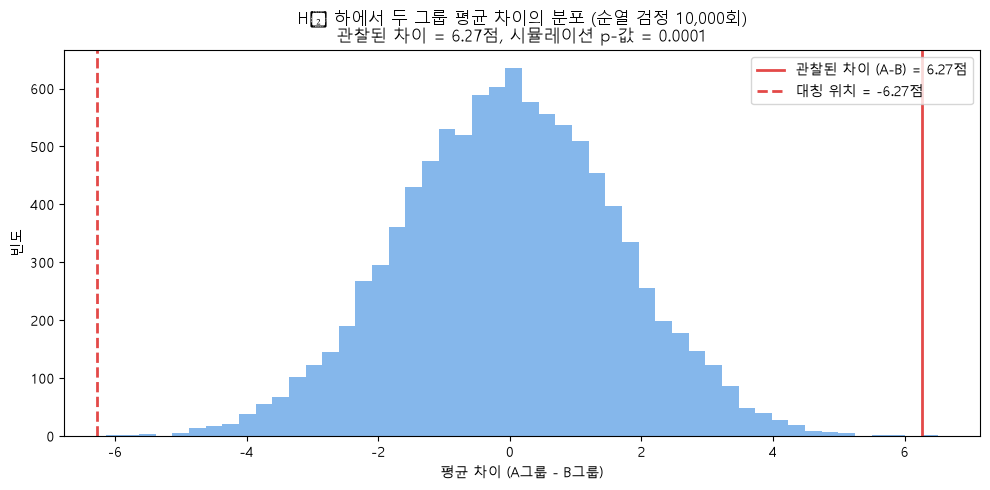

In [10]:
from scipy import stats

# ── 데이터 설정 ────────────────────────────────────
np.random.seed(0)
group_a_scores = np.random.normal(loc=85, scale=8, size=50)
group_b_scores = np.random.normal(loc=80, scale=7, size=50)
df_scores = pd.DataFrame({
    '점수': np.concatenate([group_a_scores, group_b_scores]),
    '학습방식': ['A']*50 + ['B']*50
})

# 두 그룹의 점수 분포 시각화
sns.boxplot(x='학습방식', y='점수', data=df_scores)
plt.title("학습 방식에 따른 시험 점수 분포")
plt.show()

# ── Q1. 정규성 검정 (Shapiro-Wilk) ────────────────
# H₀: 데이터는 정규분포를 따른다
stat_a, p_norm_a = stats.shapiro(group_a_scores)
stat_b, p_norm_b = stats.shapiro(group_b_scores)

print("=" * 45)
print("[Q1] 정규성 검정 (Shapiro-Wilk)")
print("=" * 45)
print(f"A그룹 - 통계량: {stat_a:.4f}, p-값: {p_norm_a:.4f}")
print(f"B그룹 - 통계량: {stat_b:.4f}, p-값: {p_norm_b:.4f}")

alpha = 0.05
for group, p in [("A", p_norm_a), ("B", p_norm_b)]:
    if p > alpha:
        print(f"→ {group}그룹: p={p:.4f} > 0.05, 정규성 가정 만족 ✓")
    else:
        print(f"→ {group}그룹: p={p:.4f} ≤ 0.05, 정규성 가정 위반 ✗")

# ── Q2. 등분산성 검정 (Levene) ─────────────────────
# H₀: 두 그룹의 분산은 같다
# H₁: 두 그룹의 분산은 다르다
stat_lev, p_lev = stats.levene(group_a_scores, group_b_scores)

print("\n" + "=" * 45)
print("[Q2] 등분산성 검정 (Levene's test)")
print("=" * 45)
print(f"통계량: {stat_lev:.4f}, p-값: {p_lev:.4f}")

if p_lev > alpha:
    print(f"→ p={p_lev:.4f} > 0.05, 등분산성 가정 만족 ✓")
    equal_var = True
else:
    print(f"→ p={p_lev:.4f} ≤ 0.05, 등분산성 가정 위반 → Welch's t-검정 사용 ✗")
    equal_var = False

# ── Q3. 이표본 t-검정 ──────────────────────────────
# H₀: 두 그룹의 평균은 같다 (μA = μB)
# H₁: 두 그룹의 평균은 다르다 (μA ≠ μB) → 양측검정
t_stat, p_ttest = stats.ttest_ind(group_a_scores, group_b_scores, equal_var=equal_var)
obs_diff = group_a_scores.mean() - group_b_scores.mean()

print("\n" + "=" * 45)
print(f"[Q3] 이표본 t-검정 (equal_var={equal_var})")
print("=" * 45)
print(f"A그룹 평균: {group_a_scores.mean():.3f}점")
print(f"B그룹 평균: {group_b_scores.mean():.3f}점")
print(f"관찰된 평균 차이 (A-B): {obs_diff:.3f}점")
print(f"t-통계량: {t_stat:.4f}")
print(f"p-값: {p_ttest:.6f}")

if p_ttest < alpha:
    print(f"→ p={p_ttest:.4f} < 0.05, 귀무가설 기각: 두 그룹의 평균은 유의미하게 다릅니다.")
else:
    print(f"→ p={p_ttest:.4f} ≥ 0.05, 귀무가설 채택: 차이가 있다는 증거가 불충분합니다.")

# ── Q4. 순열 검정 시뮬레이션 ───────────────────────
# H₀가 참이라고 가정 → 두 그룹을 합친 뒤 무작위로 재분할
all_scores = np.concatenate([group_a_scores, group_b_scores])

np.random.seed(42)
sim_diffs = []
for _ in range(10_000):
    shuffled = np.random.permutation(all_scores)
    sim_a = shuffled[:50]
    sim_b = shuffled[50:]
    sim_diffs.append(sim_a.mean() - sim_b.mean())

sim_diffs = np.array(sim_diffs)

# 시뮬레이션 p-값 (양측)
perm_p_value = np.mean(np.abs(sim_diffs) >= np.abs(obs_diff))
print("\n" + "=" * 45)
print("[Q4] 순열 검정 결과")
print("=" * 45)
print(f"시뮬레이션 p-값: {perm_p_value:.4f}")

# ── Q5. 시뮬레이션 히스토그램 ─────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(sim_diffs, bins=50, color="#85B7EB", edgecolor="none")

# 관찰된 평균 차이 세로선 (양측이므로 대칭 위치도 표시)
ax.axvline(x=obs_diff, color="#e34948", linewidth=2,
           label=f"관찰된 차이 (A-B) = {obs_diff:.2f}점")
ax.axvline(x=-obs_diff, color="#e34948", linewidth=2, linestyle="--",
           label=f"대칭 위치 = {-obs_diff:.2f}점")

ax.set_title(f"H₀ 하에서 두 그룹 평균 차이의 분포 (순열 검정 10,000회)\n"
             f"관찰된 차이 = {obs_diff:.2f}점, 시뮬레이션 p-값 = {perm_p_value:.4f}")
ax.set_xlabel("평균 차이 (A그룹 - B그룹)")
ax.set_ylabel("빈도")
ax.legend()
plt.tight_layout()
plt.show()

> Q1. 왜 p값 > 0.05이면 정규성과 등분산성을 만족하는지
 모든 가설검정은 "귀무가설을 기각할 근거가 충분한지"를 따짐
 p값은 귀무가설이 맞을때 이 데이터가 나올 확률
 즉 p값이 0.8766이라면 정규분포라고 가정해도 이 데이터가 나올 확률이 87.66%이다 = 충분히 나올 수 있는 수치이다
따라서 귀무가설을 기각할 수 없다. (귀무가설을 기각할 근거가 없다)
반대로 p값이 0.01이었다면 정규분포에서 이 데이터가 나올 확률은 1%에 불과하다. = 정규분포에서 나올 확률이 1%밖에 되지 않는다
따라서 귀무가설을 기각할 수 있다.
분산도 마찬가지로 p=0.0150이라는건 두 분산이 같다고 가정했을때 차이나는 데이터가 나올 확률이 1.5%이다.
우연이라고 보기엔 너무 드물다 -> 귀무가설(가정)을 기각할 근거가 있다

> Q2. 등분산성이 위반되었는데 왜 t-검정을 쓸 수 있는지
 Welch's t-검정은 그냥 각 그룹 분산을 따로 쓴다. "같다고 가정할 필요 없이 있는 그대로 사용"하는 방식이다. 
 여기에 자유도(df)도 Welch-Satterthwaite 공식으로 보정해서 더 정확한 p-값을 낸다.

▸
정규성 검정과 등분산성 검정의 p-값은 각각 어떻게 해석해야 하나요? 이 결과는 이표본 t-검정을 사용하는 데 문제가 없음을 보여주나요?
  - 정규성 검정결과 A그룹 p=0.8766, B그룹 p=0.8366으로 둘 다 0.05보다 훨씬 크다. 
  등분산성 같은 경우 p=0.00150으로 낮아서 등분산성에 위배되지만 Welch's t 검정으로 처리한다.

▸
Q5의 히스토그램 중심이 0에 가까운 이유는 무엇일까요?
  - 
▸
실제 관찰된 평균 차이(세로선)는 "두 방식의 효과가 같다"고 가정했을 때 우연히 나타날 수 있는 범위 안에 있나요, 벗어나나요?
  - 완전히 벗어난다. p값이 0.00001에 불과함, 즉 두 방식에서 6.27점 이상 차이난게 10,000번중 1번 일어났다는 확률

▸
이 시각적 판단과 Q3의 p-값은 어떤 관계가 있나요?
  - 세로선이 분포 바깥에 있을수록 꼬리의 면적이 작아지고 p값은 작아진다. 
▸
통계적으로 유의미한 차이가 있다면, 교육 기업은 이 결과를 어떻게 활용할 수 있을까요?
  - A방식이 B방식보다 유의미하게 높을 확률이 있다. p값이 매우 낮아서 이게 우연일 확률은 거의 없다.
  즉 A방식을 채택할 수 있다 - 통계적 근거
  

관측 빈도 (Observed Frequencies):
     액션  로맨스
20대  70   30
30대  50   60
40대  30   60


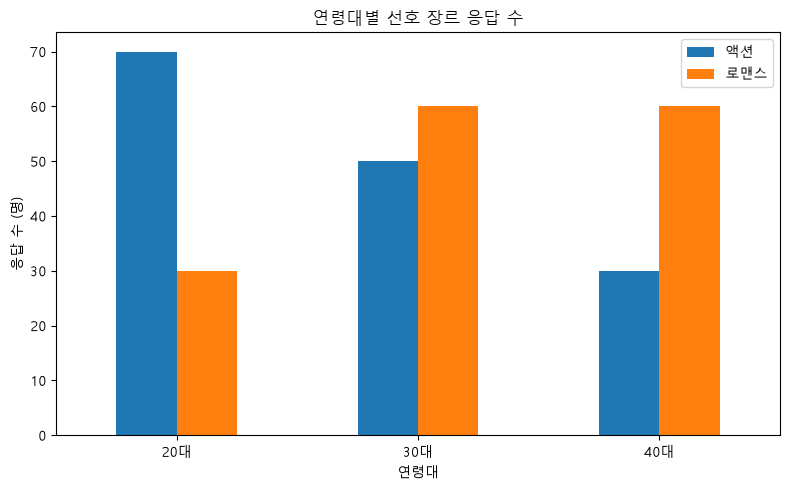


[Q2] 카이제곱 독립성 검정
카이제곱 통계량: 26.9091
자유도: 2
p-값: 0.000001

기대 빈도 (Expected Frequencies):
       액션   로맨스
20대  50.0  50.0
30대  55.0  55.0
40대  45.0  45.0

[결론]
p-값(0.0000) < 유의수준(0.05)
→ 귀무가설 기각: 연령대와 선호 장르는 서로 연관이 있습니다.

[Q3] 순열 시뮬레이션 결과
시뮬레이션 p-값: 0.0000


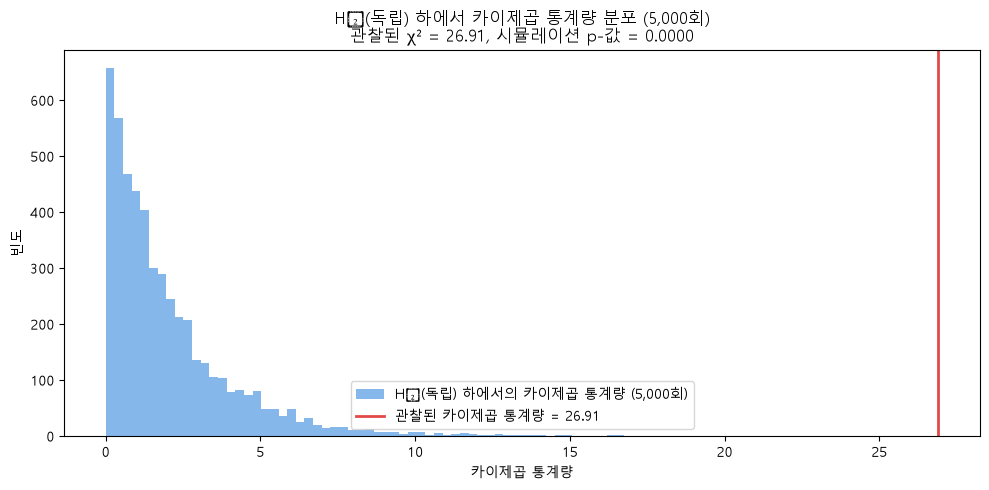

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ── 데이터 설정 ────────────────────────────────────
data = {'액션': [70, 50, 30],
        '로맨스': [30, 60, 60]}
observed = pd.DataFrame(data, index=['20대', '30대', '40대'])
print("관측 빈도 (Observed Frequencies):")
print(observed)

# 분할표 시각화
observed.plot(kind='bar', figsize=(8, 5))
plt.title("연령대별 선호 장르 응답 수")
plt.xlabel("연령대")
plt.ylabel("응답 수 (명)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ── Q1. 가설 설정 ──────────────────────────────────
# H₀: 연령대와 선호 장르는 서로 독립이다 (연관성이 없다)
# H₁: 연령대와 선호 장르는 서로 독립이 아니다 (연관성이 있다)

# ── Q2. 카이제곱 독립성 검정 ───────────────────────
chi2_stat, p_value, dof, expected = stats.chi2_contingency(observed)

expected_df = pd.DataFrame(
    expected,
    index=observed.index,
    columns=observed.columns
)

print("\n" + "=" * 48)
print("[Q2] 카이제곱 독립성 검정")
print("=" * 48)
print(f"카이제곱 통계량: {chi2_stat:.4f}")
print(f"자유도: {dof}")
print(f"p-값: {p_value:.6f}")
print("\n기대 빈도 (Expected Frequencies):")
print(expected_df.round(2))

alpha = 0.05
print(f"\n[결론]")
if p_value < alpha:
    print(f"p-값({p_value:.4f}) < 유의수준({alpha})")
    print("→ 귀무가설 기각: 연령대와 선호 장르는 서로 연관이 있습니다.")
else:
    print(f"p-값({p_value:.4f}) ≥ 유의수준({alpha})")
    print("→ 귀무가설 채택: 연관이 있다는 증거가 불충분합니다.")

# ── Q3. 시뮬레이션: H₀(독립)가 참이라면? ──────────
total = observed.values.sum()

# 각 변수의 전체 비율(주변확률)을 독립 가정의 확률로 사용
age_totals = observed.sum(axis=1)        # 연령대별 합계 (행)
genre_totals = observed.sum(axis=0)      # 장르별 합계 (열)

age_probs = (age_totals / total).values      # [20대비율, 30대비율, 40대비율]
genre_probs = (genre_totals / total).values  # [액션비율, 로맨스비율]

age_labels = observed.index.tolist()
genre_labels = observed.columns.tolist()

np.random.seed(42)
sim_chi2_stats = []

for _ in range(5_000):
    # 300명에게 연령대와 장르를 각각 '독립적으로' 무작위 할당
    sim_ages = np.random.choice(age_labels, size=total, p=age_probs)
    sim_genres = np.random.choice(genre_labels, size=total, p=genre_probs)

    # 가상 분할표 생성
    sim_table = pd.crosstab(sim_ages, sim_genres)
    # 행/열 순서를 원본과 동일하게 맞춤 (누락된 조합 대비)
    sim_table = sim_table.reindex(index=age_labels, columns=genre_labels, fill_value=0)

    sim_chi2, _, _, _ = stats.chi2_contingency(sim_table)
    sim_chi2_stats.append(sim_chi2)

sim_chi2_stats = np.array(sim_chi2_stats)

# 시뮬레이션 p-값 (관찰된 통계량 이상이 나올 비율)
sim_p_value = np.mean(sim_chi2_stats >= chi2_stat)
print("\n" + "=" * 48)
print("[Q3] 순열 시뮬레이션 결과")
print("=" * 48)
print(f"시뮬레이션 p-값: {sim_p_value:.4f}")

# ── Q4. 카이제곱 통계량 분포 히스토그램 ───────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(sim_chi2_stats, bins=60, color="#85B7EB", edgecolor="none",
        label="H₀(독립) 하에서의 카이제곱 통계량 (5,000회)")

# p-값 영역 강조
x_fill = sim_chi2_stats[sim_chi2_stats >= chi2_stat]
if len(x_fill) > 0:
    ax.hist(x_fill, bins=60, color="#e34948", edgecolor="none",
            alpha=0.7, label=f"p-값 영역 ({sim_p_value:.4f})")

ax.axvline(x=chi2_stat, color="#e34948", linewidth=2,
           label=f"관찰된 카이제곱 통계량 = {chi2_stat:.2f}")

ax.set_title(f"H₀(독립) 하에서 카이제곱 통계량 분포 (5,000회)\n"
             f"관찰된 χ² = {chi2_stat:.2f}, 시뮬레이션 p-값 = {sim_p_value:.4f}")
ax.set_xlabel("카이제곱 통계량")
ax.set_ylabel("빈도")
ax.legend()
plt.tight_layout()
plt.show()

▸
'기대 빈도'는 어떤 의미를 가지며, '관측 빈도'와의 차이가 클수록 카이제곱 통계량은 어떻게 변할까요?
  - 기대 빈도는 만약 연령대와 선호 장르가 아무런 연관이 없다면 (서로 독립이라면) 나왔어야할 빈도
  기대 빈도 = 행합계 * 열합계 / 전체, 카이제곱 통계량 공식에 따라 관측과 기대의 차이가 클수록 분자가 커지므로
  통계량도 커짐. 

▸
Q4의 히스토그램은 어떤 분포를 시각화한 것인가요? 실제 관찰된 카이제곱 통계량(세로선)은 흔한 값인가요, 극단적인 값인가요?
  - 파란 분포는 거의 0과 10 사이에 몰려있고 오른쪽 꼬리가 긴 모양이다
  26.91이상 나온값이 한번도 없었다 라는 뜻이 된다.
  
▸
유의수준 0.05에서, 연령대와 선호 장르 사이에 통계적으로 유의미한 연관성이 있다고 결론 내릴 수 있나요? 그 이유는 무엇인가요?
  - 있다. 
  근거는 귀무가설 연령대와 선호 장르는 독립이다 를 기각하고 대립가설(연령대와 선호장르는 연관이 있다)을 채택하기 때문
  통계적으로 보면 p값이 0.05보다 낮다.
  
▸
이 결과를 바탕으로 영화관은 연령대별로 어떤 상영 전략이나 프로모션을 세울 수 있을까요?

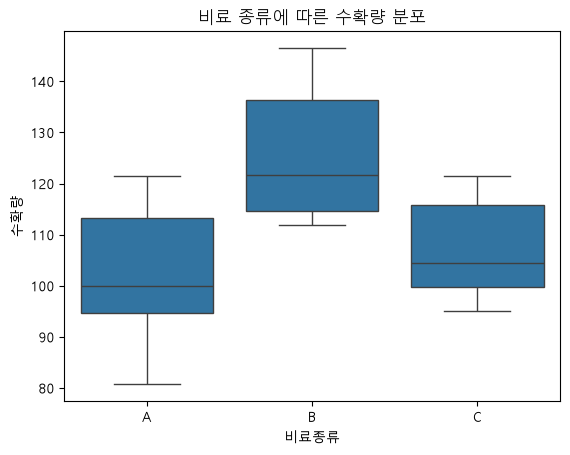

[Q1] 분산분석 (One-way ANOVA)
A 그룹 평균: 102.30kg
B 그룹 평균: 125.98kg
C 그룹 평균: 107.15kg
F-통계량: 10.3455
p-값: 0.000462
→ p=0.0005 < 0.05, 귀무가설 기각:
  적어도 하나의 비료는 평균 수확량이 다릅니다.

[Q2] Tukey's HSD 사후분석
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B  23.6754 0.0006  10.0402 37.3106   True
     A      C   4.8429 0.6569  -8.7923 18.4781  False
     B      C -18.8325 0.0054 -32.4677 -5.1972   True
-----------------------------------------------------

[Q3] 순열 시뮬레이션 결과
시뮬레이션 p-값: 0.0006


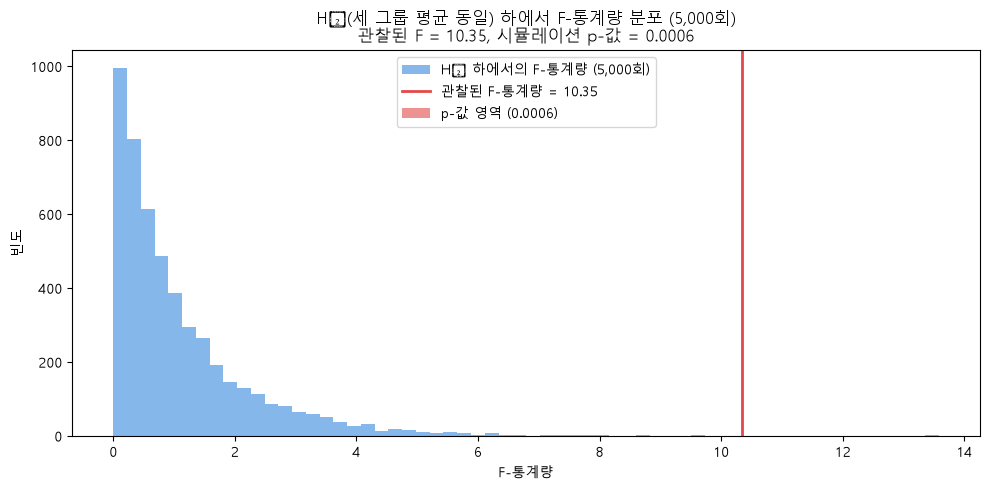


[Q5] 비료 추천 요약
A 평균: 102.30kg | B 평균: 125.98kg | C 평균: 107.15kg
평균 수확량 최고: 비료 B (125.98kg)


In [11]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ── 데이터 설정 ────────────────────────────────────
np.random.seed(123)
fertilizer_a = np.random.normal(loc=105, scale=10, size=10)
fertilizer_b = np.random.normal(loc=120, scale=12, size=10)
fertilizer_c = np.random.normal(loc=108, scale=9,  size=10)

df = pd.DataFrame({
    '수확량': np.concatenate([fertilizer_a, fertilizer_b, fertilizer_c]),
    '비료종류': ['A']*10 + ['B']*10 + ['C']*10
})

# 데이터 탐색 시각화
sns.boxplot(x='비료종류', y='수확량', data=df)
plt.title("비료 종류에 따른 수확량 분포")
plt.show()

# ── Q1. 분산분석 (ANOVA) ───────────────────────────
# H₀: 세 비료의 평균 수확량은 모두 같다 (μA = μB = μC)
# H₁: 적어도 하나 이상의 평균 수확량은 다르다
f_stat, p_anova = stats.f_oneway(fertilizer_a, fertilizer_b, fertilizer_c)

print("=" * 48)
print("[Q1] 분산분석 (One-way ANOVA)")
print("=" * 48)
print(f"A 그룹 평균: {fertilizer_a.mean():.2f}kg")
print(f"B 그룹 평균: {fertilizer_b.mean():.2f}kg")
print(f"C 그룹 평균: {fertilizer_c.mean():.2f}kg")
print(f"F-통계량: {f_stat:.4f}")
print(f"p-값: {p_anova:.6f}")

alpha = 0.05
if p_anova < alpha:
    print(f"→ p={p_anova:.4f} < 0.05, 귀무가설 기각:")
    print("  적어도 하나의 비료는 평균 수확량이 다릅니다.")
else:
    print(f"→ p={p_anova:.4f} ≥ 0.05, 귀무가설 채택:")
    print("  세 비료 간 유의미한 차이가 없습니다.")

# ── Q2. Tukey's HSD 사후분석 ──────────────────────
print("\n" + "=" * 48)
print("[Q2] Tukey's HSD 사후분석")
print("=" * 48)

if p_anova < alpha:
    tukey = pairwise_tukeyhsd(
        endog=df['수확량'],
        groups=df['비료종류'],
        alpha=0.05
    )
    print(tukey)
else:
    print("ANOVA p-값이 0.05 이상 → 사후분석 생략")

# ── Q3. 시뮬레이션: H₀가 참이라면 F-통계량은? ─────
# 전체 데이터의 평균·표준편차를 가진 단일 모집단에서
# 10개씩 3그룹을 뽑아 ANOVA → F-통계량 수집
all_data   = np.concatenate([fertilizer_a, fertilizer_b, fertilizer_c])
null_mean  = all_data.mean()
null_std   = all_data.std(ddof=1)

np.random.seed(42)
sim_f_stats = []
for _ in range(5_000):
    sim_a = np.random.normal(null_mean, null_std, size=10)
    sim_b = np.random.normal(null_mean, null_std, size=10)
    sim_c = np.random.normal(null_mean, null_std, size=10)
    f_sim, _ = stats.f_oneway(sim_a, sim_b, sim_c)
    sim_f_stats.append(f_sim)

sim_f_stats = np.array(sim_f_stats)

# 시뮬레이션 p-값 (관찰된 F 이상이 나올 비율)
sim_p = np.mean(sim_f_stats >= f_stat)
print("\n" + "=" * 48)
print("[Q3] 순열 시뮬레이션 결과")
print("=" * 48)
print(f"시뮬레이션 p-값: {sim_p:.4f}")

# ── Q4. F-통계량 분포 히스토그램 ──────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(sim_f_stats, bins=60, color="#85B7EB", edgecolor="none",
        label="H₀ 하에서의 F-통계량 (5,000회)")

ax.axvline(x=f_stat, color="#e34948", linewidth=2,
           label=f"관찰된 F-통계량 = {f_stat:.2f}")

# p-값 영역 강조
x_fill = sim_f_stats[sim_f_stats >= f_stat]
if len(x_fill) > 0:
    ax.hist(x_fill, bins=60, color="#e34948", edgecolor="none",
            alpha=0.6, label=f"p-값 영역 ({sim_p:.4f})")

ax.set_title(f"H₀(세 그룹 평균 동일) 하에서 F-통계량 분포 (5,000회)\n"
             f"관찰된 F = {f_stat:.2f}, 시뮬레이션 p-값 = {sim_p:.4f}")
ax.set_xlabel("F-통계량")
ax.set_ylabel("빈도")
ax.legend()
plt.tight_layout()
plt.show()

# ── Q5. 비료 추천 요약 출력 ────────────────────────
print("\n" + "=" * 48)
print("[Q5] 비료 추천 요약")
print("=" * 48)
print(f"A 평균: {fertilizer_a.mean():.2f}kg | "
      f"B 평균: {fertilizer_b.mean():.2f}kg | "
      f"C 평균: {fertilizer_c.mean():.2f}kg")
best = max([('A', fertilizer_a.mean()),
            ('B', fertilizer_b.mean()),
            ('C', fertilizer_c.mean())],
           key=lambda x: x[1])
print(f"평균 수확량 최고: 비료 {best[0]} ({best[1]:.2f}kg)")

### 가설설정
  - 귀무가설 : 모든 그룹의 평균은 같다
  - 대립가설 : 평균이 다른 그룹이 있다(모든 그룹이 다르다라는 말은 아님)
### ANOVA 
  - SSE(그룹내분산)와 SSB(그룹간분산)는 서로 상호배타적인 관계
  - 즉 ANOVA는 두가지 분산중 어떤것이 더 영향력이 큰지 탐구하는 방식
  
> ANOVA는 세 평균을 동시에 비교해서 이 세 데이터가 완전히 같을리 없다 만 보여줌
> 각 그룹별로 비교하기 위해서는 Tukey's HSD 사용

### SSB(그룹간분산)과 SSE(그룹내분산)
  - 그룹분리가 확실할 때는 SSB > SSE 이기 때문에 F-통계량 (그룹간분산/그룹내분산)가 크게 나옴 - 비료효과가 있다 / 귀무가설을 기각할 수 있다.
  - 그룹분리가 애매할 때는 SSB < SSE 이기 때문에 F-통계량이 작게 나온다. - 비료 효과가 없다 / 귀무가설이 참이다.

▸
ANOVA 검정의 p-값을 통해 어떤 결론을 내릴 수 있나요? 이 결과는 "세 비료가 모두 동일한 효과를 가진다"는 뜻인가요, "적어도 하나는 다르다"는 뜻인가요?
  - p값이 0.000462로 0.05보다 훨씬 작다. 따라서 귀무가설을 기각하고 **적어도 하나는 다르다**라는 결론을 가진다.
  추가로 F-통계량은 그룹간분산/그룹내분산 으로 구한다. F=10.35라는건 그룹간의 차이가 그룹내의 차이보다 10배이상 크다는 뜻이다.

  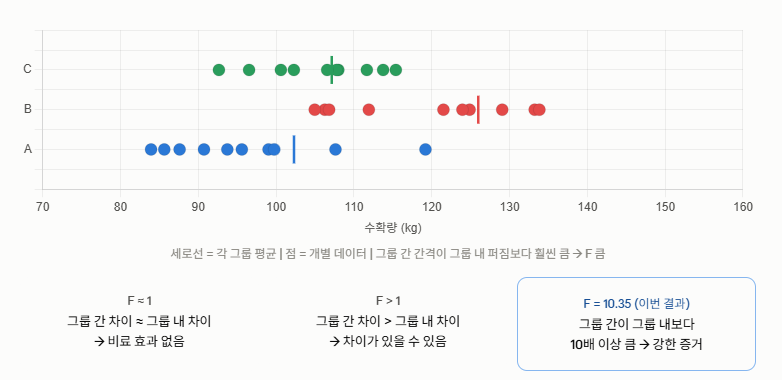

  그룹내분산보다 그룹간의분산이 훨씬 크다는 것을 볼 수 있다.

▸
Tukey's HSD 결과표의 reject 열에서 True로 표시된 조합은 무엇이며, 이는 무엇을 의미하나요?
  - A와B, B와C 에서 reject가 True라는 뜻은 두 그룹의 평균이 같다는 귀무가설을 기각해도 된다. 즉 통계적으로 유의미한 차이가 있다라는 뜻
  반면에 A와C그룹은 p값이 0.6569로 충분히 일어날 수 있다, 귀무가설이 성립한다라는 뜻이다.
  정리하면 B그룹은 A,C와 유의미하게 다르다.
  
▸
meandiff 열의 값은 어떤 정보를 주나요? 신뢰구간(lower, upper)이 0을 포함하는지 여부는 무엇을 뜻할까요?
  - meandiff는 group2 - group1의 평균을 뜻함
  A와 B그룹 23.6754 차이 = B그룹이 23.6754kg만큼 더 많다, B와 C그룹 -18.8325 = B그룹이 C그룹보다 18.8325kg만큼 더 많다

  A와 B의 신뢰구간 : [10.04, 37.31] - B가 A보다 최소 10kg, 최대 37kg 더 수확한다고 95% 확신할 수 있다.
  0이 범위 밖 : 어떤 경우에도 그 차이가 0이 아님 -> 유의미한 차이이다. / reject = True
  A와 C의 신뢰구간 : [-8.79, 18.48] - C가 A보다 최소 8.79kg 적을수도 있고 최대 18.48kg 많을수도 있다.
  0이 범위 안 : 차이가 0일 가능성이 존재 -> 유의미하지 않은 차이이다. / reject = False

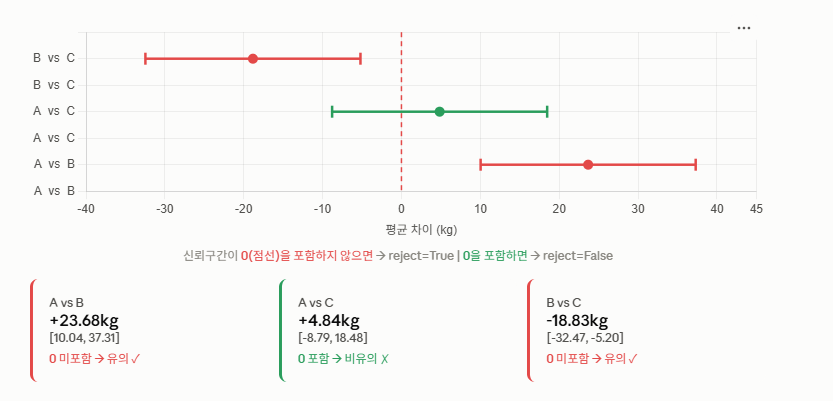

▸
그룹별 표본 크기가 10개로 작다는 점은 이 결론의 신뢰도에 어떤 영향을 줄까요? 어떻게 개선할 수 있을까요?
  - 불확실성이 크다. 
  신뢰구간을 보면 A vs B가 [10.04, 37.31]로 범위가 무려 27kg나 되고 실용적으로 쓰기엔 범위가 너무 넓다.
  - 검정력이 낮다. 
  실제로 차이가 있어도 표본이 작으면 "유의미하지 않다"라고 판단하는 2종 오류가 발생할 수 있다.
  - 개선방안
  기본적으로 표본개수를 30개 이상으로 늘리고 시행하면 중심극한정리에 의해 결과가 안정될 수 있다
  아니면 외부 변수(밭의 위치, 토질, 일조량 등)를 통제해서 그룹 내 분산을 줄이는 방법도 있다.

▸
어떤 비료가 가장 좋을지 추천
  - 비료 B
  근거 : A보다 평균 23.68kg, C보다 18.83kg 수확했고 두 차이 모두 통계적으로 유의미하다.
  A와C는 서로 유의미한 차이가 없다.
  하지만 B의 분산이 12로 가장 크고 박스플롯에서 확인할 수 있듯 가장 박스가 크다. 
  즉 평균은 높지만 밭마다 결과가 다르게 나온다. -> 따라서 비용이 비슷하다면 B를 추천하지만 B의 분산이 큰 이유를 추가로 조사하는것을 고려해볼 수 있다.
